# Rock-derived well productivity and injectivity with OPM Flow and NeqSim

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/well/rock_derived_productivity_injectivity_opm_neqsim.ipynb)

This notebook answers a practical question without assuming a productivity or injectivity index:

> For a specified reservoir pressure and producer/injector bottom-hole pressure, what rate can the rock, completion, wellbore, and surface system actually support?

The worked case derives **permeability-thickness and skin from transient evidence**, creates relative-permeability tables, lets **OPM Flow calculate the grid-scale well connection**, extracts pressure-rate relationships with `resdata`, and hands those relationships to **NeqSim current Java `master`** for wellbore and process calculations.

Use this workflow when an inflow number is about to be assumed, when injectors must satisfy a voidage requirement, or when productivity changes as flowing pressure crosses the bubble point.

**Teaching case:** all measurements and reservoir properties are synthetic. The workflow is reproducible, but its numerical results are not field-development guidance.

## What you will build

By the end, you will be able to:

1. estimate (kh) and skin from a pressure-transient data object managed by `welltestpy`;
2. generate an OPM-compatible `SWOF` table with Equinor's open-source `pyscal`;
3. run OPM Flow producer and water-injector BHP steps without supplying a connection transmissibility;
4. read `FPR`, `WBHP`, `WOPR`, `WGPR`, and `WWIR` with `resdata`;
5. turn those results into guarded pressure-to-rate functions;
6. check a voidage target and fracture-pressure margin; and
7. cross the OPM-derived IPR with a NeqSim VLP curve and pass the operating stream to a separator.

The dependency chain is intentionally narrow:

**welltestpy → pyscal → OPM Flow → resdata → NeqSim**

OPM Flow is the reservoir simulator throughout. OpenFOAM and open-DARTS are not part of this workflow.

## Python and simulation tools

| Tool | Role here | Open-source license | Why it is in the chain |
|---|---|---|---|
| [welltestpy](https://github.com/GeoStat-Framework/welltestpy) | transient-test data model and Bourdet-style derivative | MIT | keeps wells, tests, observations, and diagnostics traceable |
| [pyscal](https://github.com/equinor/pyscal) | Corey water/oil relative permeability and `SWOF` export | LGPL-3.0-or-later | turns SCAL assumptions into a simulator-ready table |
| [OPM Flow](https://opm-project.org/) | black-oil reservoir and well simulation | GPL-3.0-or-later | calculates connection factors and phase mobility from the rock/grid model |
| [resdata](https://github.com/equinor/resdata) | OPM/ECLIPSE summary reader | GPL-3.0 | extracts auditable well and field time series |
| [SciPy](https://scipy.org/) | constrained fit and monotone interpolation | BSD-3-Clause | adds the petroleum skin term and safe curve evaluation |
| [NeqSim](https://github.com/equinor/neqsim) | PVT, wellbore VLP, injection screen, and separation | Apache-2.0 | connects subsurface deliverability to production technology |

**Yes—Equinor's `pyscal` is open source and can be used.** This notebook pins `pyscal==0.15.3` and records the generated `SWOF` text. Check license compatibility and internal software-governance requirements before redistributing a combined product.

## Related NeqSim-Colab notebooks

This notebook is the inflow bridge between rock/reservoir evidence and the existing well/process examples:

- [Well nodal analysis and ECLIPSE VFPPROD lift curves](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/well/well_nodal_analysis_and_eclipse_vfp.ipynb) — detailed NeqSim VLP and lift-table export.
- [Integrated wells and production technology](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/well/integrated_wells_drilling_completion_lift_injection_intervention.ipynb) — completion, lift, injection, integrity, and intervention context.
- [Rock and reservoir flow from pore space to field development](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/rock_flow_pore_to_field_neqsim.ipynb) — digital-rock and field-scale extensions.
- [NeqSim black-oil tables and OPM Flow coupling](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/neqsim_opm_flow_blackoil_coupling.ipynb) — more complete NeqSim PVT-table generation and restart coupling.
- [From subsurface data to an OPM Flow production forecast](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/subsurface_data_to_opm_flow_production_forecast.ipynb) — seismic, petrophysics, upscaling, history evidence, and forecasting.
- [Reservoir, well, topside, and market system curves](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/reservoir_well_topside_market_system_curves.ipynb) — downstream system-curve and commercial coupling.

## 1. Reproducible runtime

The support packages are pinned. OPM Flow is installed from the official OPM Ubuntu PPA when the executable is not already available. In a standard Colab runtime, this installation can take several minutes.

The notebook then clones and builds NeqSim Java `master`. Local/CI execution may provide `OPM_FLOW_EXECUTABLE`, `NEQSIM_SOURCE_ROOT`, and `NEQSIM_SOURCE_JAR` to reuse already validated artifacts.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-matplotlib")

from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import platform
import re
import shutil
import subprocess
import sys


REQUIRED_PACKAGES = {
    "pyscal": "0.15.3",
    "resdata": "6.3.2",
    "welltestpy": "1.2.0",
    "opm": "2026.4",
    "JPype1": "1.7.1",
}


def installed_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return None


package_specs = [
    f"{name}=={required}"
    for name, required in REQUIRED_PACKAGES.items()
    if installed_version(name) != required
]
if package_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *package_specs,
        ],
        check=True,
        timeout=900,
    )

FLOW_RUN_ENV = os.environ.copy()
if os.environ.get("OPM_FLOW_PYTHONHOME"):
    FLOW_RUN_ENV["PYTHONHOME"] = os.environ["OPM_FLOW_PYTHONHOME"]
FLOW_EXECUTABLE = os.environ.get("OPM_FLOW_EXECUTABLE") or shutil.which("flow")

if FLOW_EXECUTABLE is None:
    os_release = Path("/etc/os-release").read_text(encoding="utf-8")
    if "Ubuntu" not in os_release:
        raise RuntimeError("OPM Flow installation requires an Ubuntu Colab runtime.")
    setup_commands = [
        ["apt-get", "update", "-qq"],
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "--no-install-recommends",
            "software-properties-common",
        ],
        ["add-apt-repository", "-y", "ppa:opm/ppa"],
        ["apt-get", "update", "-qq"],
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "--no-install-recommends",
            "libopm-simulators-bin",
        ],
    ]
    for command in setup_commands:
        completed = subprocess.run(
            command,
            capture_output=True,
            text=True,
            timeout=900,
        )
        if completed.returncode != 0:
            raise RuntimeError("OPM Flow installation failed:\n" + completed.stderr[-4000:])
    FLOW_EXECUTABLE = shutil.which("flow")

if FLOW_EXECUTABLE is None:
    raise RuntimeError("OPM Flow executable was not found.")

flow_version_run = subprocess.run(
    [FLOW_EXECUTABLE, "--version"],
    capture_output=True,
    env=FLOW_RUN_ENV,
    check=True,
    text=True,
    timeout=60,
)
flow_version_text = flow_version_run.stdout + flow_version_run.stderr
flow_version_match = re.search(r"flow\s+(\d{4}\.\d{2})", flow_version_text)
if flow_version_match is None:
    raise RuntimeError("Could not identify the installed OPM Flow version.")

import pandas as pd
from IPython.display import display

runtime_table = pd.DataFrame(
    {
        "runtime": ["Python", *REQUIRED_PACKAGES, "OPM Flow"],
        "version": [
            platform.python_version(),
            *(installed_version(name) for name in REQUIRED_PACKAGES),
            flow_version_match.group(1),
        ],
    }
)
display(runtime_table)

,runtime,version
0,Python,3.12.13
1,pyscal,0.15.3
2,resdata,6.3.2
3,welltestpy,1.2.0
4,opm,2026.4
5,JPype1,1.7.1
6,OPM Flow,2026.04


In [2]:
import hashlib
import jpype


def run_command(command, *, cwd=None, timeout=1200):
    result = subprocess.run(
        command,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(f"Command failed ({result.returncode}): {command}\n{tail}")
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()

if supplied_source and supplied_jar:
    neqsim_source = Path(supplied_source).resolve()
    neqsim_jar = Path(supplied_jar).resolve()
else:
    build_root = Path("/content") if Path("/content").exists() else Path.cwd()
    neqsim_source = build_root / "neqsim-java-master"
    if not neqsim_source.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(neqsim_source),
            ],
            timeout=600,
        )
    else:
        run_command(
            ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
            cwd=neqsim_source,
            timeout=600,
        )
        run_command(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=neqsim_source)
    run_command(
        ["./mvnw", "-q", "-DskipTests", "-Dmaven.javadoc.skip=true", "package"],
        cwd=neqsim_source,
        timeout=1800,
    )
    built_jars = sorted(
        path
        for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name
        and "javadoc" not in path.name
        and not path.name.startswith("original-")
    )
    shaded = [path for path in built_jars if "shaded" in path.name]
    neqsim_jar = shaded[-1] if shaded else built_jars[-1]

if not neqsim_source.is_dir() or not neqsim_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_commit = run_command(["git", "rev-parse", "HEAD"], cwd=neqsim_source)
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_jar))
    jpype.startJVM()

J = jpype.JClass
WellSystem = J("neqsim.process.equipment.reservoir.WellSystem")
class_source = str(
    WellSystem.class_.getProtectionDomain().getCodeSource().getLocation()
)
if neqsim_jar.name not in class_source:
    raise RuntimeError("NeqSim classes were not loaded from the source-built JAR.")

provenance = pd.DataFrame(
    {
        "item": ["source ref", "commit", "JAR SHA-256", "loaded class location"],
        "resolved value": [
            NEQSIM_SOURCE_REF,
            neqsim_commit,
            neqsim_jar_sha256,
            class_source,
        ],
    }
)
display(provenance)

,item,resolved value
0,source ref,master
1,commit,879eeded80135ad485de4327907fe6c3282cba08
2,JAR SHA-256,a5337f5d6ec11619d32be6827ac2bed92e664e7cb581c1...
3,loaded class location,file:/tmp/neqsim-source-validation-9rRYe3/neqs...


## 2. Engineering basis and equations

The well test uses a line-source/Theis response with a skin pressure-loss term. In hydraulic-head form,

$$
s(t)=\frac{Q}{4\pi T}W(u)+\frac{Q S_k}{2\pi T},
\qquad
u=\frac{r^2 S}{4Tt}.
$$

Hydraulic transmissivity is converted to petroleum permeability-thickness by

$$
kh=\frac{T\mu}{\rho g}.
$$

OPM Flow then constructs the completion connection factor from the cell permeability, geometry, well radius, and skin. We deliberately leave the `COMPDAT` connection transmissibility at its default. The pressure-rate indices reported later are *outputs*:

$$
PI_{eff}=\frac{q_o}{\bar p_r-p_{wf}},\qquad
II_{eff}=\frac{q_{wi}}{p_{wf}-\bar p_r}.
$$

These are state-dependent diagnostics, not timeless rock constants.

In [3]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq, least_squares


BASIS = {
    "grid": "10 × 10 × 3 Cartesian cells",
    "cell size": "100 × 100 × 10 m",
    "porosity": 0.22,
    "gross completed thickness": "30 m",
    "initial reservoir pressure": "260 bara",
    "bubble point": "200 bara at Rs = 140 Sm³/Sm³",
    "well radius": "0.10 m",
    "fracture pressure": "350 bara",
    "safe injector BHP": "330 bara",
}
display(pd.DataFrame({"assumption": BASIS.keys(), "value": BASIS.values()}))

,assumption,value
0,grid,10 × 10 × 3 Cartesian cells
1,cell size,100 × 100 × 10 m
2,porosity,0.22
3,gross completed thickness,30 m
4,initial reservoir pressure,260 bara
5,bubble point,200 bara at Rs = 140 Sm³/Sm³
6,well radius,0.10 m
7,fracture pressure,350 bara
8,safe injector BHP,330 bara


## 3. Derive (kh) and skin from a pressure transient

A synthetic drawdown observation is stored in a real `welltestpy.Campaign`. `welltestpy` supplies the well/test/observation structure and diagnostic derivative. The fit uses SciPy because the explicit petroleum skin term is added to the Theis response.

Storage is constrained independently in this example. A single late-time drawdown cannot uniquely separate storage/intercept effects from skin; treating both as unconstrained would make the fitted skin look more certain than it is.

Campaign 'Drawdowncampaign' at 'Syntheticoilfield' with 1 wells and 1 tests


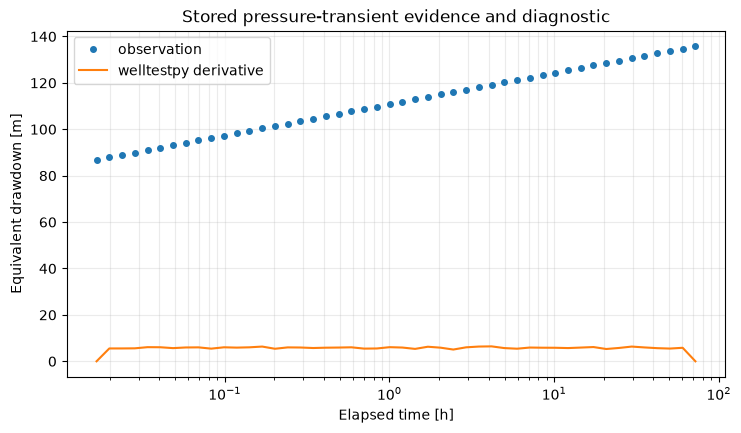

In [4]:
import welltestpy as wtp
from anaflow import theis


RHO_OIL_KG_M3 = 820.0
MU_OIL_PA_S = 0.75e-3
GRAVITY_M_S2 = 9.80665
FORMATION_THICKNESS_M = 30.0
WELL_RADIUS_M = 0.10
TEST_RATE_M3_S = 0.0035
STORAGE_COEFFICIENT = 2.5e-4
MD_TO_M2 = 9.869233e-16

TRUE_PERMEABILITY_MD = 150.0
TRUE_KH_MD_M = TRUE_PERMEABILITY_MD * FORMATION_THICKNESS_M
TRUE_SKIN = 3.5
TRUE_TRANSMISSIVITY_M2_S = (
    TRUE_KH_MD_M
    * MD_TO_M2
    * RHO_OIL_KG_M3
    * GRAVITY_M_S2
    / MU_OIL_PA_S
)

test_time_s = np.geomspace(60.0, 3.0 * 86400.0, 48)


def skin_theis_drawdown(time_s, transmissivity_m2_s, skin):
    line_source = -np.asarray(
        theis(
            time_s,
            WELL_RADIUS_M,
            STORAGE_COEFFICIENT,
            transmissivity_m2_s,
            rate=-TEST_RATE_M3_S,
            struc_grid=False,
        ),
        dtype=float,
    )
    skin_loss = TEST_RATE_M3_S * skin / (2.0 * np.pi * transmissivity_m2_s)
    return line_source + skin_loss


rng = np.random.default_rng(17)
noiseless_drawdown_m = skin_theis_drawdown(
    test_time_s,
    TRUE_TRANSMISSIVITY_M2_S,
    TRUE_SKIN,
)
observed_drawdown_m = noiseless_drawdown_m + rng.normal(
    0.0,
    0.0005 * noiseless_drawdown_m.max(),
    test_time_s.size,
)

field_site = wtp.FieldSite("Synthetic oil field")
campaign = wtp.Campaign("Drawdown campaign", fieldsite=field_site)
campaign.add_well(
    "PROD",
    radius=WELL_RADIUS_M,
    coordinates=(0.0, 0.0),
    welldepth=2500.0,
    aquiferdepth=FORMATION_THICKNESS_M,
)
drawdown_test = wtp.PumpingTest(
    "Drawdown",
    "PROD",
    TEST_RATE_M3_S,
    aquiferdepth=FORMATION_THICKNESS_M,
)
drawdown_test.add_transient_obs(
    "PROD",
    test_time_s,
    observed_drawdown_m,
)
campaign.addtests(drawdown_test)

pressure_derivative_m = wtp.process.smoothing_derivative(
    observed_drawdown_m,
    test_time_s,
)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.semilogx(test_time_s / 3600.0, observed_drawdown_m, "o", ms=4, label="observation")
ax.semilogx(test_time_s / 3600.0, pressure_derivative_m, label="welltestpy derivative")
ax.set(xlabel="Elapsed time [h]", ylabel="Equivalent drawdown [m]")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
ax.set_title("Stored pressure-transient evidence and diagnostic")
plt.show()

print(campaign)

,parameter,fitted,synthetic truth,unit
0,kh,4500.666299,4500.0,mD·m
1,permeability,150.022210,150.0,mD
2,skin,3.499881,3.5,-
3,weighted RMSE,0.000705,NaN,-


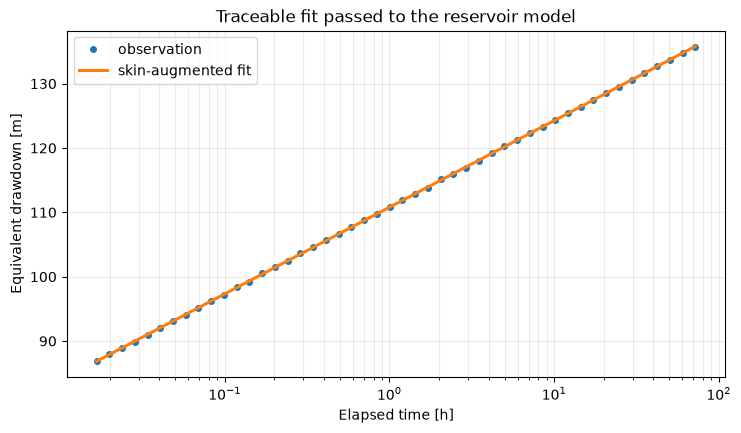

In [5]:
def transient_residual(parameters):
    transmissivity = np.exp(parameters[0])
    skin = parameters[1]
    modeled = skin_theis_drawdown(test_time_s, transmissivity, skin)
    return (modeled - observed_drawdown_m) / np.maximum(observed_drawdown_m, 0.02)


transient_fit = least_squares(
    transient_residual,
    x0=[np.log(0.7 * TRUE_TRANSMISSIVITY_M2_S), 1.0],
    bounds=(
        [np.log(TRUE_TRANSMISSIVITY_M2_S / 20.0), -2.0],
        [np.log(TRUE_TRANSMISSIVITY_M2_S * 20.0), 20.0],
    ),
)
fitted_transmissivity_m2_s = float(np.exp(transient_fit.x[0]))
fitted_skin = float(transient_fit.x[1])
fitted_kh_md_m = float(
    fitted_transmissivity_m2_s
    * MU_OIL_PA_S
    / (RHO_OIL_KG_M3 * GRAVITY_M_S2)
    / MD_TO_M2
)
fitted_permeability_md = fitted_kh_md_m / FORMATION_THICKNESS_M
fitted_drawdown_m = skin_theis_drawdown(
    test_time_s,
    fitted_transmissivity_m2_s,
    fitted_skin,
)

fit_summary = pd.DataFrame(
    {
        "parameter": ["kh", "permeability", "skin", "weighted RMSE"],
        "fitted": [
            fitted_kh_md_m,
            fitted_permeability_md,
            fitted_skin,
            np.sqrt(np.mean(transient_fit.fun**2)),
        ],
        "synthetic truth": [TRUE_KH_MD_M, TRUE_PERMEABILITY_MD, TRUE_SKIN, np.nan],
        "unit": ["mD·m", "mD", "-", "-"],
    }
)
display(fit_summary)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.semilogx(test_time_s / 3600.0, observed_drawdown_m, "o", ms=4, label="observation")
ax.semilogx(test_time_s / 3600.0, fitted_drawdown_m, lw=2.2, label="skin-augmented fit")
ax.set(xlabel="Elapsed time [h]", ylabel="Equivalent drawdown [m]")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
ax.set_title("Traceable fit passed to the reservoir model")
plt.show()

## 4. Turn SCAL assumptions into `SWOF` with `pyscal`

`pyscal` does not estimate relative permeability from this pressure transient. It makes the SCAL assumptions explicit and exports them in the exact table format consumed by OPM Flow. Replace the Corey parameters below with laboratory interpretation and uncertainty ranges for a field case.

SWOF
-- 
-- pyscal: 0.15.3
-- swirr=0 swl=0.12 swcr=0.12 sorw=0.18
-- Corey krw, nw=2.2, krwend=1, krwmax=1
-- Corey krow, now=2.5, kroend=1
-- krw = krow @ sw=0.45452
-- Zero capillary pressure
-- SW     KRW       KROW      PC        
0.1200000 0.0000000 1.0000000 0.0000000
0.1400000 0.0004009 0.9300947 0.0000000
0.1600000 0.0018421 0.8632066 0.0000000


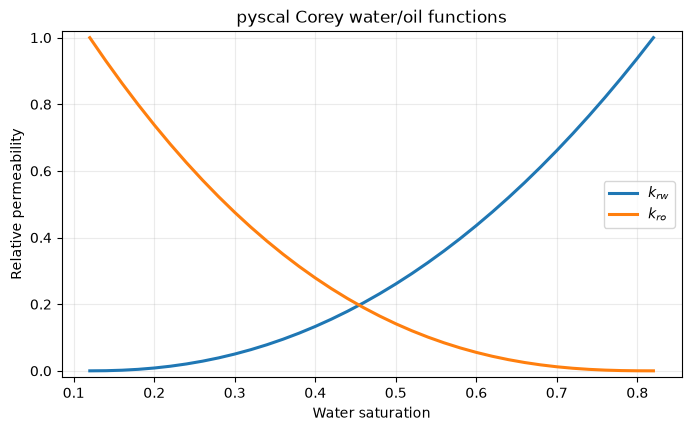

,SW,KRW,KROW
0,0.12,0.000000,1.000000
1,0.22,0.013829,0.680194
2,0.32,0.063540,0.431201
3,0.42,0.155043,0.246834
4,0.52,0.291955,0.120243
5,0.62,0.477000,0.043634
6,0.72,0.712389,0.007714
7,0.82,1.000000,0.000000


In [6]:
from pyscal import WaterOil


water_oil = WaterOil(h=0.02, sorw=0.18, swl=0.12)
water_oil.add_corey_water(nw=2.2)
water_oil.add_corey_oil(now=2.5)
swof_text = water_oil.SWOF()
scal_table = water_oil.table.loc[water_oil.table["SW"] <= 0.82 + 1.0e-9].copy()

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.plot(scal_table["SW"], scal_table["KRW"], lw=2.2, label="$k_{rw}$")
ax.plot(scal_table["SW"], scal_table["KROW"], lw=2.2, label="$k_{ro}$")
ax.set(xlabel="Water saturation", ylabel="Relative permeability", ylim=(-0.02, 1.02))
ax.grid(True, alpha=0.25)
ax.legend()
ax.set_title("pyscal Corey water/oil functions")
plt.show()

display(scal_table.iloc[::5][["SW", "KRW", "KROW"]].reset_index(drop=True))
print("\n".join(swof_text.splitlines()[:12]))

## 5. Build OPM Flow well tests from the evidence

Two groups of independent black-oil pressure steps plus one depletion trajectory are run (13 small OPM cases in total):

- a producer at 260 bara, with flowing pressure approaching/crossing the 200-bara bubble point;
- a water injector at 260 bara with increasing BHP and an established water bank around the completion; and
- a producer held at 100 bara while reservoir pressure depletes from 260 bara through the bubble point.

The 10 × 10 × 3 grid receives the fitted permeability. The completion receives the fitted skin and a 0.20 m well diameter. The `COMPDAT` transmissibility field remains defaulted (`1*`), so OPM calculates it from rock and geometry rather than accepting a user-supplied PI/II. The injector uses a water-swept near-well state; startup injectivity from irreducible water saturation would require a separate transient displacement study.

In [7]:
FLOW_WORK_ROOT = (
    Path("/content/neqsim_well_inflow_run")
    if Path("/content").exists()
    else Path("/tmp/neqsim_well_inflow_run")
)
FLOW_WORK_ROOT.mkdir(parents=True, exist_ok=True)

P_BUBBLE_BARA = 200.0


def saturated_rs(reservoir_pressure_bara):
    return float(
        np.interp(
            reservoir_pressure_bara,
            [50.0, 100.0, 150.0, 200.0],
            [20.0, 60.0, 100.0, 140.0],
            left=20.0,
            right=140.0,
        )
    )


def build_opm_deck(
    case_name,
    reservoir_pressure_bara,
    bhp_controls_bara,
    kind,
    duration_days=1.0,
    repeat_steps=1,
):
    if kind not in {"producer", "injector"}:
        raise ValueError("kind must be 'producer' or 'injector'")
    well_name = "PROD" if kind == "producer" else "INJ"
    preferred_phase = "OIL" if kind == "producer" else "WATER"
    summary_keywords = (
        "WOPR\n  'PROD' /\nWGPR\n  'PROD' /\nWWPR\n  'PROD' /"
        if kind == "producer"
        else "WWIR\n  'INJ' /"
    )
    controls = []
    tstep_value = (
        f"{repeat_steps}*{duration_days:.4f}"
        if repeat_steps > 1
        else f"{duration_days:.4f}"
    )
    for bhp in bhp_controls_bara:
        if kind == "producer":
            controls.append(
                f"WCONPROD\n  'PROD' 'OPEN' 'BHP' 5* {bhp:.4f} /\n/\nTSTEP\n  {tstep_value} /"
            )
        else:
            controls.append(
                f"WCONINJE\n  'INJ' 'WATER' 'OPEN' 'BHP' 2* {bhp:.4f} /\n/\nTSTEP\n  {tstep_value} /"
    )
    rs_initial = saturated_rs(reservoir_pressure_bara)
    water_contact_depth_m = 3000.0 if kind == "producer" else 2400.0

    return f"""RUNSPEC
TITLE
  {case_name} ROCK-DERIVED WELL PRESSURE TEST

DIMENS
  10 10 3 /

OIL
GAS
WATER
DISGAS
METRIC

START
  1 'JAN' 2026 /

WELLDIMS
  1 3 1 1 /

TABDIMS
/

EQLDIMS
/

UNIFOUT

GRID
INIT
DX
  300*100.0 /
DY
  300*100.0 /
DZ
  300*10.0 /
TOPS
  100*2500.0 /
PORO
  300*0.22 /
PERMX
  300*{fitted_permeability_md:.8f} /
PERMY
  300*{fitted_permeability_md:.8f} /
PERMZ
  300*{0.1 * fitted_permeability_md:.8f} /
/

PROPS
DENSITY
  820.0 1.20 1018.0 /

ROCK
  260.0 4.0E-5 /

PVTW
  260.0 1.020 4.0E-5 0.35 0.0 /

PVDG
  1.0 0.98 0.011
  50.0 0.025 0.014
  100.0 0.013 0.017
  150.0 0.0090 0.020
  200.0 0.0070 0.023
  260.0 0.0060 0.027
  350.0 0.0051 0.032 /

PVTO
  20.0 50.0 1.10 0.90 /
  60.0 100.0 1.20 0.75 /
  100.0 150.0 1.30 0.62 /
  140.0 200.0 1.42 0.52
        260.0 1.39 0.57
        350.0 1.35 0.64 /
/

{swof_text}

SGOF
  0.00 0.0000 1.0000 0.0
  0.05 0.0020 0.9300 0.0
  0.10 0.0100 0.8000 0.0
  0.20 0.0600 0.5500 0.0
  0.30 0.1600 0.3200 0.0
  0.40 0.3300 0.1500 0.0
  0.50 0.5500 0.0500 0.0
  0.60 0.7800 0.0100 0.0
  0.70 0.9300 0.0010 0.0
  0.88 1.0000 0.0000 0.0 /

SOLUTION
EQUIL
  2515.0 {reservoir_pressure_bara:.6f} {water_contact_depth_m:.1f} 0.0 2200.0 0.0 1 0 0 /

RSVD
  2400.0 {rs_initial:.6f}
  2700.0 {rs_initial:.6f} /

SUMMARY
FPR
{summary_keywords}
WBHP
  '{well_name}' /

SCHEDULE
RPTRST
  'BASIC=1' /

WELSPECS
  '{well_name}' 'FIELD' 5 5 2515.0 '{preferred_phase}' /
/

COMPDAT
  '{well_name}' 5 5 1 3 'OPEN' 1* 1* {2.0 * WELL_RADIUS_M:.4f} 1* {fitted_skin:.6f} /
/

{chr(10).join(controls)}

END
"""


sweep_specs = {
    "PROD_HIGH": (260.0, [250.0, 240.0, 230.0, 220.0, 205.0, 190.0], "producer"),
    "INJ_HIGH": (260.0, [270.0, 285.0, 300.0, 315.0, 330.0, 345.0], "injector"),
}
case_specs = {
    f"{sweep_name}_{step:02d}": {
        "pressure": pressure,
        "bhp": [bhp],
        "kind": kind,
        "sweep": sweep_name,
        "duration_days": 1.0,
        "repeat_steps": 1,
    }
    for sweep_name, (pressure, bhps, kind) in sweep_specs.items()
    for step, bhp in enumerate(bhps, start=1)
}
case_specs["DEPLETION"] = {
    "pressure": 260.0,
    "bhp": [100.0],
    "kind": "producer",
    "sweep": "DEPLETION",
    "duration_days": 50.0,
    "repeat_steps": 12,
}

deck_paths = {}
for case_name, spec in case_specs.items():
    deck_path = FLOW_WORK_ROOT / f"{case_name}.DATA"
    deck_path.write_text(
        build_opm_deck(
            case_name,
            spec["pressure"],
            spec["bhp"],
            spec["kind"],
            spec["duration_days"],
            spec["repeat_steps"],
        ),
        encoding="utf-8",
    )
    deck_paths[case_name] = deck_path

print(f"Wrote {len(deck_paths)} OPM decks to {FLOW_WORK_ROOT}")
print("COMPDAT:", next(line.strip() for line in deck_paths["PROD_HIGH_01"].read_text().splitlines() if "'PROD' 5 5" in line))

Wrote 13 OPM decks to /tmp/neqsim_well_inflow_run
COMPDAT: 'PROD' 5 5 1 3 'OPEN' 1* 1* 0.2000 1* 3.499881 /


In [8]:
def run_flow_case(case_name, deck_path):
    output_dir = FLOW_WORK_ROOT / f"{case_name}_OUTPUT"
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True)
    completed = subprocess.run(
        [FLOW_EXECUTABLE, f"--output-dir={output_dir}", str(deck_path)],
        capture_output=True,
        env=FLOW_RUN_ENV,
        text=True,
        timeout=300,
    )
    combined_log = completed.stdout + completed.stderr
    (output_dir / "flow-console.log").write_text(combined_log, encoding="utf-8")
    if completed.returncode != 0:
        raise RuntimeError(f"OPM Flow failed for {case_name}:\n" + combined_log[-5000:])
    if "End of simulation" not in combined_log:
        raise RuntimeError(f"OPM Flow did not report completion for {case_name}.")
    return output_dir / case_name


flow_case_bases = {
    case_name: run_flow_case(case_name, deck_path)
    for case_name, deck_path in deck_paths.items()
}
print(f"OPM Flow {flow_version_match.group(1)} completed {len(flow_case_bases)} cases: two pressure sweeps and one depletion run.")

OPM Flow 2026.04 completed 13 cases: two pressure sweeps and one depletion run.


## 6. Extract pressure-rate evidence with `resdata`

The simulator summaries are the source of the inflow relationship. Using average field pressure is appropriate for this homogeneous teaching model; a field workflow should select a representative pressure region and account for interference, boundaries, and completion-level pressures.

In [9]:
import contextlib
import io

resdata_import_messages = io.StringIO()
warnings.filterwarnings(
    "ignore",
    message="resdata.util.util.Version is deprecated.*",
    category=DeprecationWarning,
)
warnings.simplefilter("ignore", DeprecationWarning)
with warnings.catch_warnings(), contextlib.redirect_stderr(resdata_import_messages):
    warnings.simplefilter("ignore", DeprecationWarning)
    import resdata
    warnings.simplefilter("ignore", DeprecationWarning)
    from resdata.summary import Summary
import_messages = resdata_import_messages.getvalue()
if import_messages and "resdata.util.util.Version is deprecated" not in import_messages:
    raise RuntimeError(import_messages)


def read_flow_sweep(sweep_name, kind, state):
    rows = []
    case_names = sorted(name for name in flow_case_bases if name.startswith(sweep_name + "_"))
    for case_name in case_names:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", DeprecationWarning)
            summary = Summary(str(flow_case_bases[case_name]))
        rows.append(
            {
                "case": case_name,
                "state": state,
                "time_day": float(summary.numpy_vector("YEARS")[-1] * 365.25),
                "FPR_bara": float(summary.numpy_vector("FPR")[-1]),
                "WBHP_bara": float(summary.numpy_vector("WBHP:PROD" if kind == "producer" else "WBHP:INJ")[-1]),
                "rate_sm3_day": float(summary.numpy_vector("WOPR:PROD" if kind == "producer" else "WWIR:INJ")[-1]),
                "WGPR_sm3_day": float(summary.numpy_vector("WGPR:PROD")[-1]) if kind == "producer" else np.nan,
            }
        )
    frame = pd.DataFrame(rows)
    if kind == "producer":
        frame["pressure_difference_bar"] = frame["FPR_bara"] - frame["WBHP_bara"]
    else:
        frame["pressure_difference_bar"] = frame["WBHP_bara"] - frame["FPR_bara"]
    frame["effective_index_sm3_day_bar"] = frame["rate_sm3_day"] / frame["pressure_difference_bar"]
    frame["kind"] = kind
    return frame


def read_depletion_trajectory():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        summary = Summary(str(flow_case_bases["DEPLETION"]))
    frame = pd.DataFrame(
        {
            "case": "DEPLETION",
            "state": "fixed-BHP depletion through bubble point",
            "time_day": summary.numpy_vector("YEARS") * 365.25,
            "FPR_bara": summary.numpy_vector("FPR"),
            "WBHP_bara": summary.numpy_vector("WBHP:PROD"),
            "rate_sm3_day": summary.numpy_vector("WOPR:PROD"),
            "WGPR_sm3_day": summary.numpy_vector("WGPR:PROD"),
        }
    )
    frame = frame.loc[
        (frame["rate_sm3_day"] > 0.0)
        & np.isclose(frame["WBHP_bara"], 100.0)
        & (frame["FPR_bara"] >= 155.0)
    ].copy()
    frame["pressure_difference_bar"] = frame["FPR_bara"] - frame["WBHP_bara"]
    frame["effective_index_sm3_day_bar"] = frame["rate_sm3_day"] / frame["pressure_difference_bar"]
    frame["kind"] = "producer depletion"
    return frame.reset_index(drop=True)


producer_high = read_flow_sweep("PROD_HIGH", "producer", "initial pressure above bubble point")
injector_high = read_flow_sweep("INJ_HIGH", "injector", "water injection above bubble point")
depletion_trajectory = read_depletion_trajectory()
inflow_results = pd.concat([producer_high, injector_high, depletion_trajectory], ignore_index=True)

display(
    inflow_results[
        [
            "case",
            "FPR_bara",
            "WBHP_bara",
            "rate_sm3_day",
            "pressure_difference_bar",
            "effective_index_sm3_day_bar",
        ]
    ].round(3)
)

,case,FPR_bara,WBHP_bara,rate_sm3_day,pressure_difference_bar,effective_index_sm3_day_bar
0,PROD_HIGH_01,262.137,250.0,327.811,12.137,27.010
1,PROD_HIGH_02,261.997,240.0,605.051,21.997,27.506
2,PROD_HIGH_03,261.858,230.0,881.959,31.858,27.684
3,PROD_HIGH_04,261.721,220.0,1158.607,41.721,27.770
4,PROD_HIGH_05,261.552,205.0,1577.476,56.552,27.894
5,PROD_HIGH_06,261.383,190.0,1992.537,71.383,27.913
6,INJ_HIGH_01,261.036,270.0,536.285,8.964,59.826
7,INJ_HIGH_02,262.590,285.0,1340.931,22.410,59.837
8,INJ_HIGH_03,264.145,300.0,2145.841,35.855,59.847
9,INJ_HIGH_04,265.700,315.0,2951.013,49.300,59.858


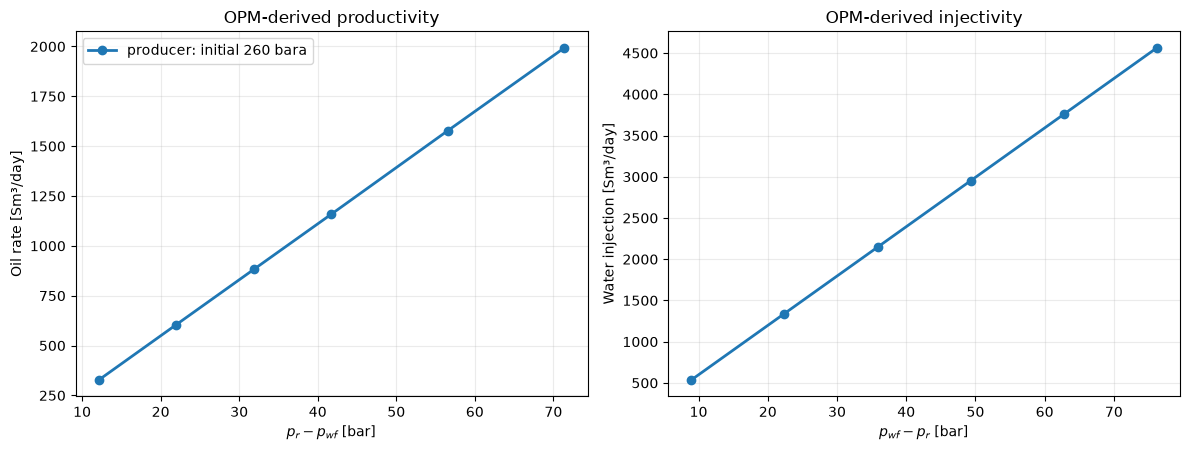

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
axes[0].plot(
    producer_high["pressure_difference_bar"],
    producer_high["rate_sm3_day"],
    "o-",
    lw=2,
    label="producer: initial 260 bara",
)
axes[0].set(xlabel="$p_r-p_{wf}$ [bar]", ylabel="Oil rate [Sm³/day]", title="OPM-derived productivity")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(
    injector_high["pressure_difference_bar"],
    injector_high["rate_sm3_day"],
    "o-",
    lw=2,
    color="tab:blue",
)
axes[1].set(xlabel="$p_{wf}-p_r$ [bar]", ylabel="Water injection [Sm³/day]", title="OPM-derived injectivity")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Independent radial-flow reasonableness check

A Peaceman-style effective radius gives a useful magnitude check, but it is not a replacement for OPM. The analytical expression omits evolving saturation, phase behavior, discretization details, and transient storage.

In [11]:
CELL_DX_M = 100.0
CELL_DY_M = 100.0
PEACEMAN_RADIUS_M = 0.14 * np.sqrt(CELL_DX_M**2 + CELL_DY_M**2)
BO_AT_260 = 1.39
MU_OIL_AT_260_PA_S = 0.57e-3

analytical_pi_sm3_day_bar = (
    2.0
    * np.pi
    * fitted_permeability_md
    * MD_TO_M2
    * FORMATION_THICKNESS_M
    / (
        MU_OIL_AT_260_PA_S
        * BO_AT_260
        * (np.log(PEACEMAN_RADIUS_M / WELL_RADIUS_M) + fitted_skin)
    )
    * 86400.0
    * 1.0e5
)
opm_pi_sm3_day_bar = float(producer_high["effective_index_sm3_day_bar"].iloc[:3].median())
analytical_difference_pct = 100.0 * (opm_pi_sm3_day_bar / analytical_pi_sm3_day_bar - 1.0)

display(
    pd.DataFrame(
        {
            "screen": ["radial Darcy/Peaceman", "OPM Flow early steps"],
            "PI [Sm³/day/bar]": [analytical_pi_sm3_day_bar, opm_pi_sm3_day_bar],
            "interpretation": ["single-state magnitude check", "grid/PVT/SCAL result"],
        }
    )
)
print(f"OPM differs from the analytical screen by {analytical_difference_pct:.1f}%.")

OPM differs from the analytical screen by -20.6%.


,screen,PI [Sm³/day/bar],interpretation
0,radial Darcy/Peaceman,34.631342,single-state magnitude check
1,OPM Flow early steps,27.506127,grid/PVT/SCAL result


## 7. Pressure-to-rate functions

The functions below use monotone shape-preserving interpolation and reject extrapolation. They answer the design question directly, but only inside the simulated pressure-difference range and for the 260-bara reservoir states represented by the pressure sweeps.

A real asset model should generate additional curves over pressure, saturation, completion, and uncertainty—not silently reuse one curve through depletion. The subsequent depletion run demonstrates why.

In [12]:
def rate_interpolator(frame):
    pressure_difference = np.r_[0.0, frame["pressure_difference_bar"].to_numpy()]
    rate = np.r_[0.0, frame["rate_sm3_day"].to_numpy()]
    order = np.argsort(pressure_difference)
    return PchipInterpolator(pressure_difference[order], rate[order], extrapolate=False)


producer_interpolator = rate_interpolator(producer_high)
injector_interpolator = rate_interpolator(injector_high)


def production_rate_sm3_day(reservoir_pressure_bara, flowing_bhp_bara):
    drawdown = reservoir_pressure_bara - flowing_bhp_bara
    if drawdown < 0.0:
        raise ValueError("Producer flowing BHP must not exceed reservoir pressure.")
    rate = float(producer_interpolator(drawdown))
    if not np.isfinite(rate):
        raise ValueError("Requested producer drawdown is outside the OPM-derived range.")
    return rate


def injection_rate_sm3_day(injection_bhp_bara, reservoir_pressure_bara):
    pressure_up = injection_bhp_bara - reservoir_pressure_bara
    if pressure_up < 0.0:
        raise ValueError("Injector BHP must not be below reservoir pressure.")
    rate = float(injector_interpolator(pressure_up))
    if not np.isfinite(rate):
        raise ValueError("Requested injector pressure difference is outside the OPM-derived range.")
    return rate


example_production_rate = production_rate_sm3_day(260.0, 210.0)
example_injection_rate = injection_rate_sm3_day(325.0, 260.0)

direct_answers = pd.DataFrame(
    {
        "calculation": ["production", "water injection"],
        "reservoir pressure [bara]": [260.0, 260.0],
        "well BHP [bara]": [210.0, 325.0],
        "estimated rate [Sm³/day]": [example_production_rate, example_injection_rate],
        "curve state": ["260-bara producer", "260-bara injector"],
    }
)
display(direct_answers.round(2))

,calculation,reservoir pressure [bara],well BHP [bara],estimated rate [Sm³/day],curve state
0,production,260.0,210.0,1392.52,260-bara producer
1,water injection,260.0,325.0,3891.54,260-bara injector


## 8. Why productivity is not constant below the bubble point

Once average oil pressure falls below the bubble point, gas evolves, oil relative permeability changes, and deliverability declines. The fixed-BHP trajectory below separates this state change from the independent pressure-step IPR used above.

Along the fixed-BHP depletion path, effective PI falls by 54.0% before the 155-bara cutoff.


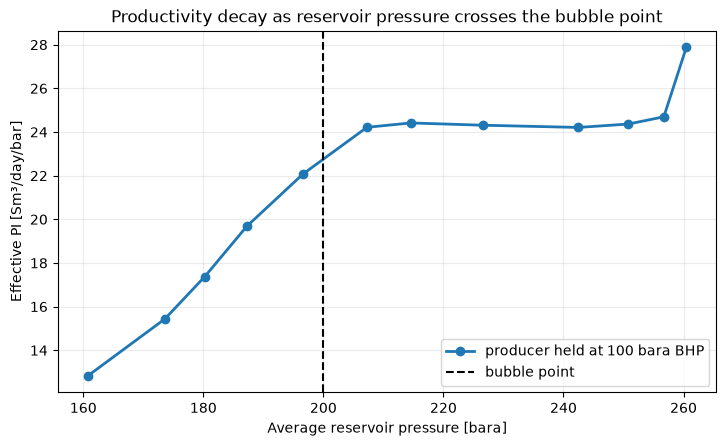

In [13]:
depletion_pi_start = float(depletion_trajectory["effective_index_sm3_day_bar"].iloc[0])
depletion_pi_end = float(depletion_trajectory["effective_index_sm3_day_bar"].iloc[-1])
productivity_decay_pct = 100.0 * (1.0 - depletion_pi_end / depletion_pi_start)

fig, ax = plt.subplots(figsize=(8.5, 4.7))
ax.plot(
    depletion_trajectory["FPR_bara"],
    depletion_trajectory["effective_index_sm3_day_bar"],
    "o-",
    lw=2,
    label="producer held at 100 bara BHP",
)
ax.axvline(P_BUBBLE_BARA, color="black", ls="--", label="bubble point")
ax.set(
    xlabel="Average reservoir pressure [bara]",
    ylabel="Effective PI [Sm³/day/bar]",
    title="Productivity decay as reservoir pressure crosses the bubble point",
)
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

print(f"Along the fixed-BHP depletion path, effective PI falls by {productivity_decay_pct:.1f}% before the 155-bara cutoff.")

## 9. Can the injector meet the voidage requirement?

For a first screen, the produced reservoir oil volume is (q_o B_o), while the injected reservoir water volume is (q_{wi}B_w). The required surface water rate at target voidage-replacement ratio is therefore

$$
q_{wi,req}=VRR\frac{q_oB_o}{B_w}.
$$

This simplified balance omits produced water, free-gas voidage, aquifer support, and compressibility. Those terms should be added for a full surveillance calculation.

In [14]:
TARGET_VRR = 1.0
PRODUCER_COUNT = 3
BW_AT_260 = 1.02
SAFE_INJECTOR_BHP_BARA = 330.0
FRACTURE_PRESSURE_BARA = 350.0

total_oil_rate_sm3_day = PRODUCER_COUNT * example_production_rate
required_water_sm3_day = TARGET_VRR * total_oil_rate_sm3_day * BO_AT_260 / BW_AT_260
safe_injector_capacity_sm3_day = injection_rate_sm3_day(SAFE_INJECTOR_BHP_BARA, 260.0)
injector_count = math.ceil(required_water_sm3_day / safe_injector_capacity_sm3_day)
achieved_vrr_one_injector = safe_injector_capacity_sm3_day * BW_AT_260 / (total_oil_rate_sm3_day * BO_AT_260)

voidage_screen = pd.DataFrame(
    {
        "quantity": [
            "producer wells",
            "oil rate per producer",
            "total oil rate used in screen",
            "required water rate",
            "one-injector safe capacity",
            "VRR with one injector",
            "injectors required",
            "fracture-pressure margin",
        ],
        "value": [
            PRODUCER_COUNT,
            example_production_rate,
            total_oil_rate_sm3_day,
            required_water_sm3_day,
            safe_injector_capacity_sm3_day,
            achieved_vrr_one_injector,
            injector_count,
            FRACTURE_PRESSURE_BARA - SAFE_INJECTOR_BHP_BARA,
        ],
        "unit": ["wells", "Sm³/day", "Sm³/day", "Sm³/day", "Sm³/day", "-", "wells", "bar"],
    }
)
display(voidage_screen.round(3))

,quantity,value,unit
0,producer wells,3.000,wells
1,oil rate per producer,1392.518,Sm³/day
2,total oil rate used in screen,4177.555,Sm³/day
3,required water rate,5692.943,Sm³/day
4,one-injector safe capacity,4191.167,Sm³/day
5,VRR with one injector,0.736,-
6,injectors required,2.000,wells
7,fracture-pressure margin,20.000,bar


## 10. Hand the result to NeqSim

Two complementary handoffs are shown:

1. `InjectionWellModel` receives the fitted rock/skin and the pressure limit as a transparent single-phase wellbore screen. Its difference from OPM quantifies why saturation-dependent reservoir simulation remains the governing inflow calculation.
2. The OPM producer IPR is crossed with a NeqSim `WellSystem` VLP curve. The resulting operating stream is flashed in a NeqSim separator.

In [15]:
InjectionWellModel = J("neqsim.process.fielddevelopment.reservoir.InjectionWellModel")

neqsim_injector = InjectionWellModel()
neqsim_injector.setWellType(InjectionWellModel.InjectionType.WATER_INJECTOR)
neqsim_injector.setReservoirPressure(260.0, "bara")
neqsim_injector.setFormationPermeability(fitted_permeability_md, "mD")
neqsim_injector.setFormationThickness(FORMATION_THICKNESS_M, "m")
neqsim_injector.setDrainageRadius(PEACEMAN_RADIUS_M)
neqsim_injector.setWellboreRadius(WELL_RADIUS_M)
neqsim_injector.setSkinFactor(fitted_skin)
neqsim_injector.setWaterViscosity(0.35)
neqsim_injector.setWellDepth(2500.0, "m")
neqsim_injector.setTubingID(0.1016, "m")
neqsim_injector.setFracturePressure(FRACTURE_PRESSURE_BARA, "bara")
neqsim_injector.setMaxBHP(SAFE_INJECTOR_BHP_BARA, "bara")
neqsim_injector.setSurfaceInjectionPressure(160.0, "bara")

neqsim_injection_result = neqsim_injector.calculateMaximumRate()
opm_ii_at_limit = safe_injector_capacity_sm3_day / (SAFE_INJECTOR_BHP_BARA - 260.0)

injection_handoff = pd.DataFrame(
    {
        "model": ["OPM Flow, SCAL/grid state", "NeqSim single-phase radial screen"],
        "injectivity [Sm³/day/bar]": [
            opm_ii_at_limit,
            neqsim_injection_result.getInjectivityIndex(),
        ],
        "rate at limit [Sm³/day]": [
            safe_injector_capacity_sm3_day,
            neqsim_injection_result.getAchievableRate(),
        ],
        "role": ["governing reservoir inflow", "wellbore/pump screening bound"],
    }
)
display(injection_handoff.round(3))

,model,injectivity [Sm³/day/bar],rate at limit [Sm³/day],role
0,"OPM Flow, SCAL/grid state",59.874,4191.167,governing reservoir inflow
1,NeqSim single-phase radial screen,76.856,5379.954,wellbore/pump screening bound


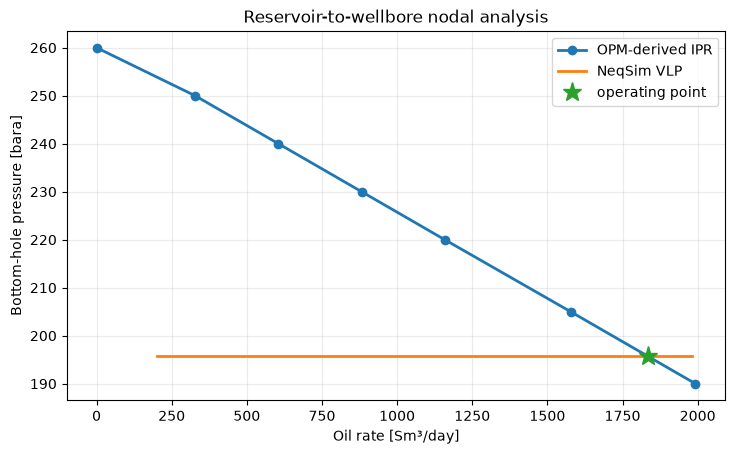

,quantity,value,unit
0,operating oil rate,1834.030815,Sm³/day
1,operating BHP,195.744370,bara
2,tubing-head pressure,40.000000,bara
3,nodal residual,0.000000,bar


In [16]:
SystemPrEos = J("neqsim.thermo.system.SystemPrEos")
Stream = J("neqsim.process.equipment.stream.Stream")

OIL_COMPOSITION = {
    "methane": 0.30,
    "ethane": 0.05,
    "propane": 0.04,
    "n-butane": 0.04,
    "n-pentane": 0.04,
    "n-hexane": 0.05,
    "n-heptane": 0.07,
    "n-octane": 0.08,
    "n-nonane": 0.08,
    "nC10": 0.10,
    "nC12": 0.08,
    "nC16": 0.07,
}


def make_neqsim_oil(temperature_c, pressure_bara):
    fluid = SystemPrEos(temperature_c + 273.15, pressure_bara)
    for component, fraction in OIL_COMPOSITION.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


reservoir_fluid = make_neqsim_oil(90.0, 260.0)
reservoir_stream = Stream("OPM-derived producer feed", reservoir_fluid)
reservoir_stream.setFlowRate(example_production_rate, "Sm3/day")
reservoir_stream.run()

neqsim_well = WellSystem("Producer with OPM IPR", reservoir_stream)
neqsim_well.setTubingLength(2500.0, "m")
neqsim_well.setTubingDiameter(4.5, "in")
neqsim_well.setTubingRoughness(2.5e-5)
neqsim_well.setInclination(90.0)
neqsim_well.setBottomHoleTemperature(90.0, "C")
neqsim_well.setWellheadTemperature(30.0, "C")
neqsim_well.setWellheadPressure(40.0, "bara")
neqsim_well.setVLPSolverMode(WellSystem.VLPSolverMode.SIMPLIFIED)

opm_q = np.r_[0.0, producer_high["rate_sm3_day"].to_numpy()]
opm_bhp = np.r_[260.0, producer_high["WBHP_bara"].to_numpy()]
rate_order = np.argsort(opm_q)
ipr_bhp_from_rate = PchipInterpolator(opm_q[rate_order], opm_bhp[rate_order], extrapolate=False)

rate_grid = np.linspace(200.0, 0.995 * opm_q.max(), 70)
vlp_array = np.asarray(neqsim_well.generateVLPCurve(rate_grid), dtype=float)
vlp_bhp_from_rate = PchipInterpolator(vlp_array[0], vlp_array[1], extrapolate=False)

def nodal_residual(rate_sm3_day):
    return float(ipr_bhp_from_rate(rate_sm3_day) - vlp_bhp_from_rate(rate_sm3_day))


residual_grid = np.array([nodal_residual(rate) for rate in rate_grid])
brackets = np.where(residual_grid[:-1] * residual_grid[1:] <= 0.0)[0]
if len(brackets) != 1:
    raise RuntimeError("Expected exactly one OPM-IPR/NeqSim-VLP crossing.")
lower = float(rate_grid[brackets[0]])
upper = float(rate_grid[brackets[0] + 1])
operating_rate_sm3_day = brentq(nodal_residual, lower, upper)
operating_bhp_bara = float(ipr_bhp_from_rate(operating_rate_sm3_day))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(opm_q, opm_bhp, "o-", lw=2, label="OPM-derived IPR")
ax.plot(vlp_array[0], vlp_array[1], lw=2, label="NeqSim VLP")
ax.plot(operating_rate_sm3_day, operating_bhp_bara, "*", ms=14, label="operating point")
ax.set(xlabel="Oil rate [Sm³/day]", ylabel="Bottom-hole pressure [bara]", title="Reservoir-to-wellbore nodal analysis")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

display(
    pd.DataFrame(
        {
            "quantity": ["operating oil rate", "operating BHP", "tubing-head pressure", "nodal residual"],
            "value": [operating_rate_sm3_day, operating_bhp_bara, 40.0, nodal_residual(operating_rate_sm3_day)],
            "unit": ["Sm³/day", "bara", "bara", "bar"],
        }
    ).round(6)
)

In [17]:
Separator = J("neqsim.process.equipment.separator.Separator")
ProcessSystem = J("neqsim.process.processmodel.ProcessSystem")

wellhead_fluid = make_neqsim_oil(30.0, 40.0)
wellhead_stream = Stream("Nodal operating stream", wellhead_fluid)
wellhead_stream.setFlowRate(operating_rate_sm3_day, "Sm3/day")
first_stage_separator = Separator("First-stage separator", wellhead_stream)

surface_process = ProcessSystem()
surface_process.add(wellhead_stream)
surface_process.add(first_stage_separator)
surface_process.run()

gas_out = first_stage_separator.getGasOutStream()
liquid_out = first_stage_separator.getLiquidOutStream()
feed_mass_kg_hr = float(wellhead_stream.getFlowRate("kg/hr"))
outlet_mass_kg_hr = float(gas_out.getFlowRate("kg/hr") + liquid_out.getFlowRate("kg/hr"))
separator_mass_error = (outlet_mass_kg_hr - feed_mass_kg_hr) / feed_mass_kg_hr

process_handoff = pd.DataFrame(
    {
        "stream": ["wellhead feed", "separator gas", "separator liquid"],
        "standard volume [Sm³/day]": [
            wellhead_stream.getFlowRate("Sm3/day"),
            gas_out.getFlowRate("Sm3/day"),
            liquid_out.getFlowRate("Sm3/day"),
        ],
        "mass [kg/h]": [
            wellhead_stream.getFlowRate("kg/hr"),
            gas_out.getFlowRate("kg/hr"),
            liquid_out.getFlowRate("kg/hr"),
        ],
    }
)
display(process_handoff.round(4))

,stream,standard volume [Sm³/day],mass [kg/h]
0,wellhead feed,1834.0308,283.4840
1,separator gas,303.8046,9.5641
2,separator liquid,1530.2263,273.9200


## 11. Executable engineering checks

These checks are intentionally physical as well as computational. A green notebook means the evidence recovered the synthetic rock, Flow honored the expected pressure-rate directions, interpolation stayed inside its domain, the nodal crossing closed, and the process mass balance closed.

In [18]:
checks = []


def check(condition, description):
    assert bool(condition), description
    checks.append(description)


check(transient_fit.success, "transient optimizer converged")
check(abs(fitted_kh_md_m / TRUE_KH_MD_M - 1.0) < 0.02, "well test recovers kh within 2%")
check(abs(fitted_skin / TRUE_SKIN - 1.0) < 0.05, "well test recovers skin within 5%")
check(np.isclose(scal_table["KRW"].iloc[0], 0.0), "pyscal water endpoint is closed")
check(np.isclose(scal_table["KROW"].iloc[-1], 0.0), "pyscal oil endpoint is closed")
check(all("End of simulation" in (base.parent / "flow-console.log").read_text() for base in flow_case_bases.values()), "all OPM cases report completion")
check(np.all(np.diff(producer_high["rate_sm3_day"]) > 0.0), "producer rate increases with drawdown")
check(np.all(np.diff(injector_high["rate_sm3_day"]) > 0.0), "injector rate increases with BHP")
check(abs(analytical_difference_pct) < 35.0, "OPM PI is within 35% of the radial-flow screen")
check(example_production_rate > 0.0 and example_injection_rate > 0.0, "direct pressure-to-rate answers are positive")
check(productivity_decay_pct > 20.0, "depleted-case productivity decay is material")
check(SAFE_INJECTOR_BHP_BARA < FRACTURE_PRESSURE_BARA, "injector limit preserves fracture margin")
check(injector_count >= 1, "voidage screen returns a physical well count")
check(neqsim_jar.name in class_source, "NeqSim classes come from the source-built JAR")
check(abs(nodal_residual(operating_rate_sm3_day)) < 1.0e-7, "OPM-IPR/NeqSim-VLP crossing closes")
check(abs(separator_mass_error) < 1.0e-10, "NeqSim separator mass balance closes")

print(f"Fitted kh: {fitted_kh_md_m:.2f} mD·m; fitted skin: {fitted_skin:.3f}")
print(f"Production at 260/210 bara: {example_production_rate:.1f} Sm³/day")
print(f"Injection at 325/260 bara: {example_injection_rate:.1f} Sm³/day")
print(f"Nodal operating point: {operating_rate_sm3_day:.1f} Sm³/day at {operating_bhp_bara:.2f} bara")
print(f"All {len(checks)} engineering checks passed.")

Fitted kh: 4500.67 mD·m; fitted skin: 3.500
Production at 260/210 bara: 1392.5 Sm³/day
Injection at 325/260 bara: 3891.5 Sm³/day
Nodal operating point: 1834.0 Sm³/day at 195.74 bara
All 16 engineering checks passed.


## Interpretation and decision rules

- **Do not enter PI/II as an unexplained constant.** Preserve the well-test fit, SCAL table, grid/completion assumptions, simulator version, and extracted curve together.
- **Use the curve only for its state and domain.** A pressure pair is not enough when saturation, bubble-point state, completion, or interference has changed.
- **Treat OPM as the inflow authority and NeqSim as the wellbore/process authority.** The NeqSim single-phase injection screen is useful for hydraulics and pump bounds; the OPM curve contains the grid and mobility effects.
- **Constrain injection by both voidage and fracture margin.** If one injector misses VRR at safe BHP, add completion capacity, wells, or revise the production target—do not extrapolate beyond the simulated pressure range.
- **Recalibrate through time.** Repeat well tests, match pressure/rate history, and update skin, saturation functions, and completion status before forecasting.

## Limitations

This compact teaching model assumes homogeneous Cartesian rock, isotropic horizontal permeability, one completion, no faults, no aquifer, no geomechanical coupling, no capillary pressure, no hysteresis, and synthetic PVT/SCAL/PTA evidence. Average field pressure is used as reservoir pressure. Each IPR/II pressure point starts from the same initial state; the separate fixed-BHP depletion path illustrates state change but is not a matched long-term forecast.

Before field use, add history matching; pressure gauges and rate-allocation uncertainty; completion-level diagnostics; relative-permeability uncertainty; well interference and boundaries; non-Darcy effects where relevant; produced-water/free-gas voidage; fracture initiation/propagation constraints; and scenario ensembles over rock, fluid, skin, and facility conditions.

## Exercises

1. Replace the synthetic drawdown with a real rate/pressure history and propagate the fitted (kh)/skin covariance to the OPM curves.
2. Generate low/base/high `pyscal` ensembles for Corey exponents and endpoints. Which uncertainty dominates injector count?
3. Add partial completion and anisotropic permeability. Compare OPM's connection factor with the analytical Peaceman screen.
4. Add produced water and free-gas terms to the voidage calculation and track VRR through depletion.
5. Generate a pressure–saturation family of OPM curves and replace the two-state selector with a bounded two-dimensional interpolator.
6. Continue with the linked nodal-analysis notebook and export a `VFPPROD` family for OPM schedule control.